In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold 
import matplotlib.pyplot as plt

In [4]:
# Se cargan los datos. 

data=pd.read_csv('car_details_v3.csv', sep=',', encoding = 'utf-8')

In [5]:
# Cantidad de datos y número de variables

data.shape

(8128, 13)

In [6]:
# Mostrar los datos

data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [7]:
# Es recomendable que todos los pasos de limpieza y preparación se realicen sobre otro archivo.

data_t = data

data_t=data_t.dropna()
data_t=data_t.drop_duplicates()

data_t['mileage'] = data_t['mileage'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['mileage'] = pd.to_numeric(data_t['mileage'], errors='coerce')
data_t['engine'] = data_t['engine'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['engine'] = pd.to_numeric(data_t['engine'], errors='coerce')
data_t['max_power'] = data_t['max_power'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['max_power'] = pd.to_numeric(data_t['max_power'], errors='coerce')

data_t.shape
data_t.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


In [8]:
# Transformación de las variables de entrada.

data_t = pd.get_dummies(data_t, columns=['fuel', 'seller_type', 'owner'], dtype=int, drop_first=True)
data_t=data_t.drop(['name'], axis=1)
data_t=data_t.drop(['torque'], axis=1)

In [9]:
codificacion = LabelEncoder()

data_t['transmission']=codificacion.fit_transform(data_t['transmission'])

In [10]:
# Podemos ver cómo quedaron nuestro datos

data_t.head()

,year,selling_price,km_driven,transmission,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,1,23.40,1248.0,74.00,5.0,1,0,0,1,0,0,0,0,0
1,2014,370000,120000,1,21.14,1498.0,103.52,5.0,1,0,0,1,0,0,1,0,0
2,2006,158000,140000,1,17.70,1497.0,78.00,5.0,0,0,1,1,0,0,0,0,1
3,2010,225000,127000,1,23.00,1396.0,90.00,5.0,1,0,0,1,0,0,0,0,0
4,2007,130000,120000,1,16.10,1298.0,88.20,5.0,0,0,1,1,0,0,0,0,0


In [11]:
#revisión del total de registros

data_t.shape

(6717, 17)

In [12]:
# Se selecciona la variable objetivo

Y=data_t['transmission']
X=data_t.drop(['transmission'], axis=1)

In [13]:
# Dividir los datos en entrenamiento y test

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [14]:
# Crear el objeto de arbol de decisión. 

arbol = DecisionTreeClassifier(criterion='entropy', random_state=0)

In [15]:
# Entrenar el modelo de arbol de decisión con los datos de entrenamiento

arbol = arbol.fit(X_train,Y_train)

In [16]:
# Determinamos las predicciones del modelo sobre el conjunto test.

y_pred = arbol.predict(X_test)

In [17]:
# Se genera la matriz de confusión

confusion_matrix(Y_test, y_pred)

array([[  71,   37],
       [  57, 1179]])

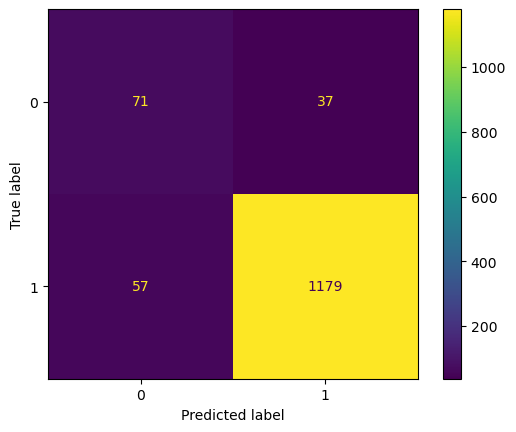

In [18]:
# Se puede visualizar la matriz de confusión

ConfusionMatrixDisplay.from_estimator(arbol, X_test, Y_test)  
plt.show()  

In [19]:
print('Exactitud: %.2f' % accuracy_score(Y_test, y_pred))
print("Recall: {:.2f}".format(recall_score(Y_test, y_pred, average='weighted')))
print("Precisión: {:.2f}".format(precision_score(Y_test, y_pred, average='weighted')))
print("Puntuación F1: {:.2f}".format(f1_score(Y_test, y_pred, average='weighted')))

Exactitud: 0.93
Recall: 0.93
Precisión: 0.94
Puntuación F1: 0.93


In [21]:
# Mostrar reporte de clasificación

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.66      0.60       108
           1       0.97      0.95      0.96      1236

    accuracy                           0.93      1344
   macro avg       0.76      0.81      0.78      1344
weighted avg       0.94      0.93      0.93      1344



In [22]:
# Crear el objeto de arbol de decisión. Utilicemos como criterio de pureza la entropía.

arbol = DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=0)
arbol = arbol.fit(X_train,Y_train)
y_pred = arbol.predict(X_test)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.56      0.56       108
           1       0.96      0.96      0.96      1236

    accuracy                           0.93      1344
   macro avg       0.76      0.76      0.76      1344
weighted avg       0.93      0.93      0.93      1344



In [23]:
# Fijemos el número de particiones. 

particiones = KFold(n_splits=10, shuffle=True, random_state = 0)

In [24]:
# Establecemos el espacio de búsqueda para los hiperparámetros que deseamos ajustar. 

param_grid = {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10],'min_samples_split':[2, 3, 4, 5]}

In [25]:
# Definimos el modelo sin ningún valor de estos hiperparámetros

arbol = DecisionTreeClassifier(class_weight='balanced', random_state=0)

In [26]:
# Ahora utilizamos GridSearch sobre el grid definido y con 10 particiones en la validación cruzada.

mejor_modelo = GridSearchCV(arbol, param_grid, cv=particiones)
mejor_modelo.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 6, 8, 10],
                         'min_samples_split': [2, 3, 4, 5]})

In [27]:
# Podemos ver cual fue el resultado de la búsqueda (mejores valores de hiperparámetros)

mejor_modelo.best_params_

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 3}

In [28]:
# Obtener el mejor modelo.

modelo_final = mejor_modelo.best_estimator_

y_pred = modelo_final.predict(X_test)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.34      0.76      0.47       108
           1       0.98      0.87      0.92      1236

    accuracy                           0.86      1344
   macro avg       0.66      0.81      0.69      1344
weighted avg       0.93      0.86      0.88      1344



In [29]:
y_pred_test = modelo_final.predict_proba(X_test.iloc[[20]])

In [30]:
print(y_pred_test)

[[0. 1.]]


In [31]:
modelo_final.classes_

array([0, 1])